<a href="https://colab.research.google.com/github/ayushi261/fake-job-posting/blob/main/notebooks/fake_job_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd


file_path = '/content/drive/MyDrive/fake_job_postings[1].csv'
df = pd.read_csv(file_path)

# Verify all 18 columns are present
print(f"Dataset Shape: {df.shape}")
print("\n--- All 18 Raw Columns Loaded ---")
print(df.columns.tolist())

Dataset Shape: (17880, 18)

--- All 18 Raw Columns Loaded ---
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [3]:
# 1. Target Column (y) and Feature Matrix (X) separation
y = df['fraudulent']

# 2. Drop non-predictive ID column and target variable
# Note: 'job_id' is excluded from model features here
X_raw = df.drop(columns=['job_id', 'fraudulent'])

# 3. Concatenate Text Columns into 1 Unified Feature
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')

df['full_text'] = (
    df['title'] + " " +
    df['company_profile'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['benefits']
)

# 4. Feature Engineering on Metadata
df['has_salary'] = df['salary_range'].notna().astype(int)
df['has_company_logo'] = df['has_company_logo'].fillna(0).astype(int)
df['has_questions'] = df['has_questions'].fillna(0).astype(int)
df['telecommuting'] = df['telecommuting'].fillna(0).astype(int)

print("\nFeature processing setup complete! You are ready for train/test split and modeling.")


Feature processing setup complete! You are ready for train/test split and modeling.


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = str(text).lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove punctuation & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(cleaned)

print("Cleaning text data... (takes ~1 minute)")
df['clean_text'] = df['full_text'].apply(clean_text)
print("Text cleaning finished!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Cleaning text data... (takes ~1 minute)
Text cleaning finished!


In [5]:
from sklearn.model_selection import train_test_split

# Define feature columns and target
X_cols = [
    'clean_text', 'has_company_logo', 'has_questions',
    'telecommuting', 'has_salary'
]

X = df[X_cols]
y = df['fraudulent']

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 14304
Testing samples:  3576


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 2)), 'clean_text'),
        ('num', StandardScaler(), ['has_company_logo', 'has_questions', 'telecommuting', 'has_salary'])
    ]
)

# Fit transformer on training set and transform both
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Processed Feature Matrix Shape: {X_train_prep.shape}")

Processed Feature Matrix Shape: (14304, 3004)


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import MinMaxScaler

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

results = []

for name, model in models.items():
    # Naive Bayes requires non-negative values
    if name == "Naive Bayes":
        scaler = MinMaxScaler()
        X_tr = scaler.fit_transform(X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep)
        X_te = scaler.transform(X_test_prep.toarray() if hasattr(X_test_prep, 'toarray') else X_test_prep)
    else:
        X_tr, X_te = X_train_prep, X_test_prep

    # Train
    model.fit(X_tr, y_train)

    # Predict
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]

    # Metrics
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, probs), 4)
    })

# Display comparison table
import pandas as pd
results_df = pd.DataFrame(results)
print("=== MODEL EVALUATION METRICS ===")
print(results_df.to_string(index=False))

=== MODEL EVALUATION METRICS ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
        Naive Bayes    0.8557     0.2398  0.9133    0.3798   0.9591
Logistic Regression    0.9533     0.5097  0.9075    0.6528   0.9859
      Random Forest    0.9776     0.9794  0.5491    0.7037   0.9899


In [8]:
def predict_fake_job(title, company_profile, description, requirements, benefits,
                     has_logo, has_questions, telecommuting, salary_range):

    # Combine text
    full_text = f"{title} {company_profile} {description} {requirements} {benefits}"
    clean = clean_text(full_text)

    has_salary = 1 if pd.notna(salary_range) and str(salary_range).strip() != "" else 0

    input_data = pd.DataFrame([{
        'clean_text': clean,
        'has_company_logo': has_logo,
        'has_questions': has_questions,
        'telecommuting': telecommuting,
        'has_salary': has_salary
    }])

    # Transform input
    transformed_input = preprocessor.transform(input_data)

    # Predict with Logistic Regression
    clf = models["Logistic Regression"]
    prob = clf.predict_proba(transformed_input)[0][1]
    is_fake = prob >= 0.5

    print("\n--- PREDICTION RESULT ---")
    print(f"Status       : {'⚠️ FRAUDULENT (FAKE)' if is_fake else '✅ LEGITIMATE (REAL)'}")
    print(f"Fraud Risk   : {prob * 100:.2f}%")

# Test on a scam sample
predict_fake_job(
    title="Data Entry Specialist - Earn $500/day",
    company_profile="", # Missing profile
    description="Work 2 hours a day from home. Send $50 for starter kit.",
    requirements="No experience required. Personal bank account needed.",
    benefits="Daily payout via wire transfer.",
    has_logo=0,
    has_questions=0,
    telecommuting=1,
    salary_range="100000-150000"
)


--- PREDICTION RESULT ---
Status       : ⚠️ FRAUDULENT (FAKE)
Fraud Risk   : 97.24%


/tmp/ipykernel_1510/1553909180.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='fraudulent', data=df, palette=['#2b5c8f', '#d9534f'])


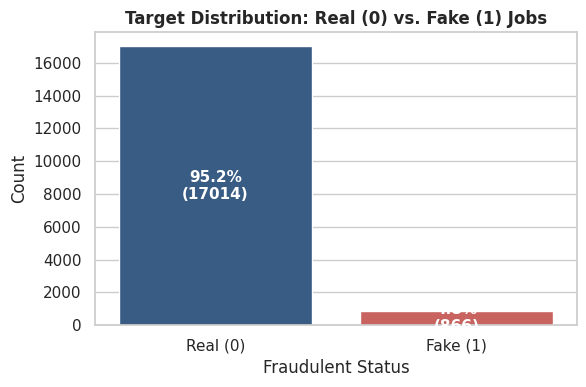

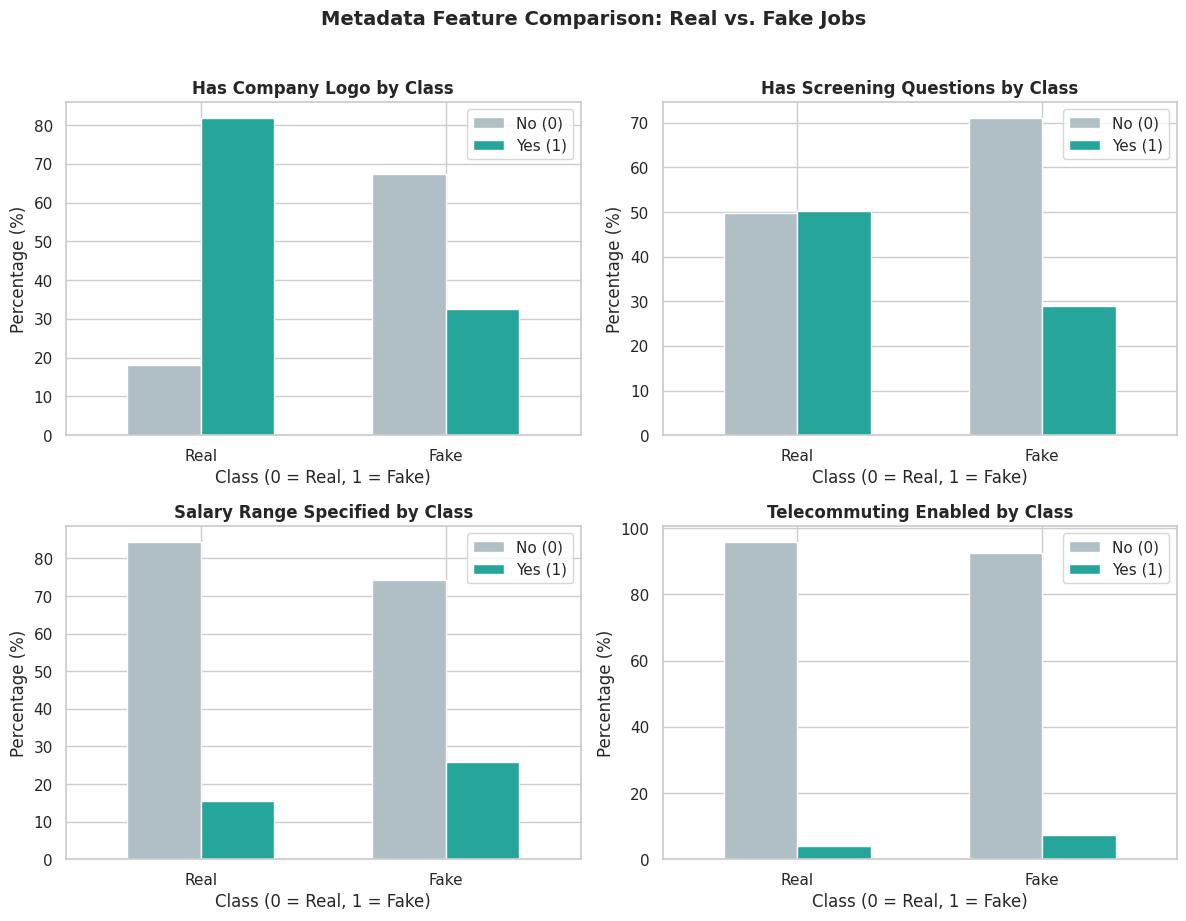

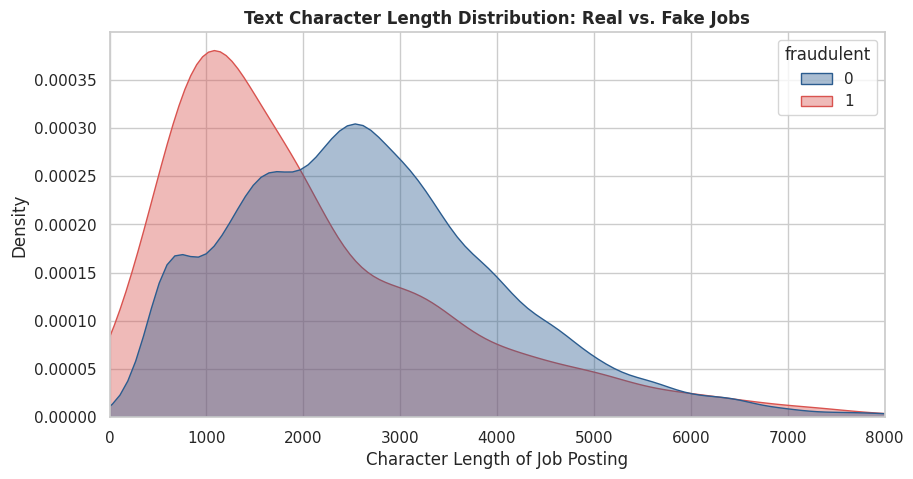

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# 1. Target Class Imbalance Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='fraudulent', data=df, palette=['#2b5c8f', '#d9534f'])
plt.title('Target Distribution: Real (0) vs. Fake (1) Jobs', fontsize=12, fontweight='bold')
plt.xlabel('Fraudulent Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Real (0)', 'Fake (1)'])

# Add percentage labels on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%\n({int(p.get_height())})'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Binary Metadata Comparison (Logo, Questions, Salary, Telecommuting)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

features_to_plot = [
    ('has_company_logo', 'Has Company Logo'),
    ('has_questions', 'Has Screening Questions'),
    ('has_salary', 'Salary Range Specified'),
    ('telecommuting', 'Telecommuting Enabled')
]

for idx, (col, title) in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]

    # Calculate percentage per class
    prop_df = df.groupby('fraudulent')[col].value_counts(normalize=True).unstack() * 100
    prop_df.plot(kind='bar', ax=ax, color=['#b0bec5', '#26a69a'], width=0.6)

    ax.set_title(f'{title} by Class', fontweight='bold')
    ax.set_xlabel('Class (0 = Real, 1 = Fake)')
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(['Real', 'Fake'], rotation=0)
    ax.legend(['No (0)', 'Yes (1)'], loc='upper right')

plt.suptitle('Metadata Feature Comparison: Real vs. Fake Jobs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. Text Length Distribution Comparison
plt.figure(figsize=(10, 5))
df['text_length'] = df['full_text'].apply(len)
sns.kdeplot(data=df, x='text_length', hue='fraudulent', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True, alpha=0.4)
plt.xlim(0, 8000)
plt.title('Text Character Length Distribution: Real vs. Fake Jobs', fontsize=12, fontweight='bold')
plt.xlabel('Character Length of Job Posting')
plt.ylabel('Density')
plt.show()

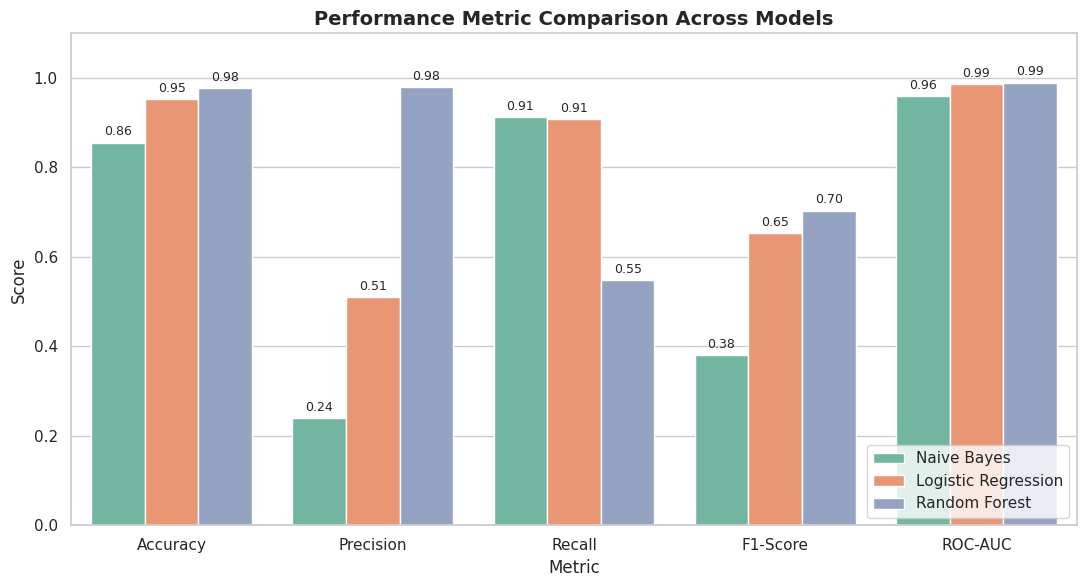

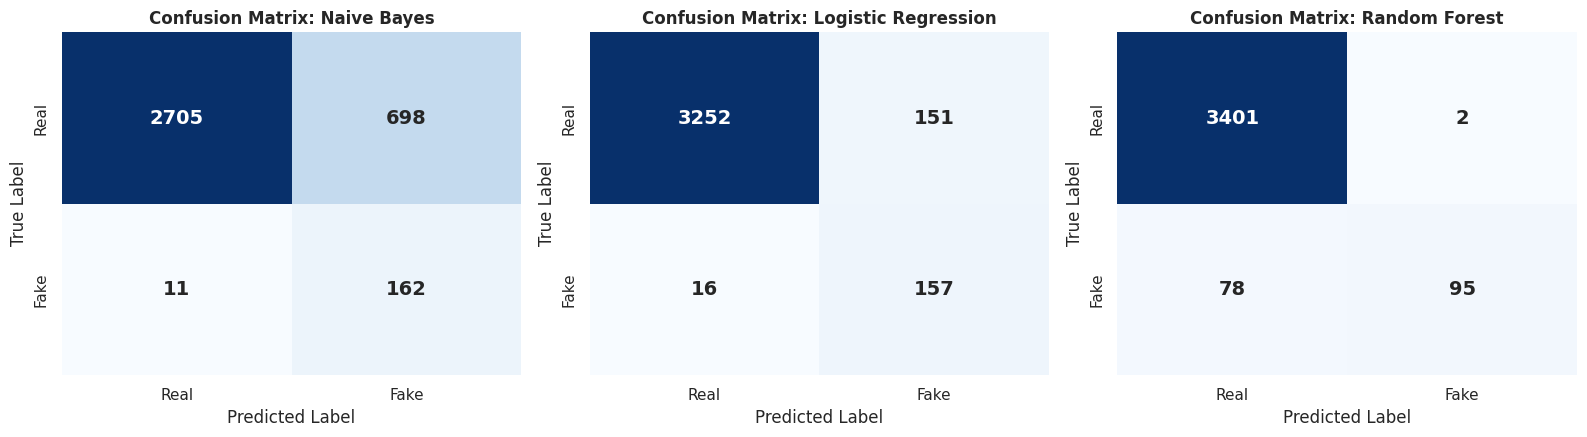

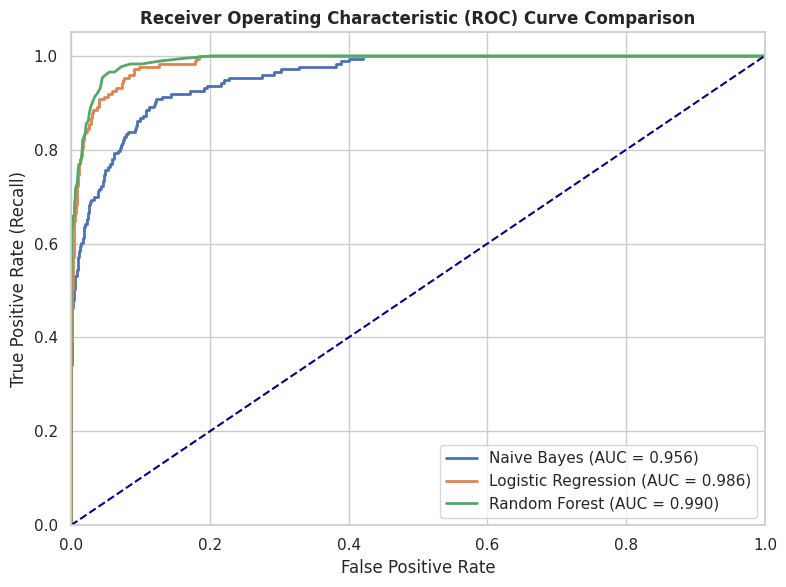

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Multi-Metric Model Comparison Bar Chart
metrics_melted = pd.melt(results_df, id_vars=['Model'], var_name='Metric', value_name='Score')

plt.figure(figsize=(11, 6))
chart = sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='Set2')
plt.title('Performance Metric Comparison Across Models', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)

# Annotate values on top of bars
for p in chart.patches:
    if p.get_height() > 0:
        chart.annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, rotation=0, xytext=(0, 3),
                       textcoords='offset points')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 2. Confusion Matrix Subplots for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, (name, model) in enumerate(models.items()):
    if name == "Naive Bayes":
        X_te = MinMaxScaler().fit_transform(X_test_prep.toarray() if hasattr(X_test_prep, 'toarray') else X_test_prep)
    else:
        X_te = X_test_prep

    preds = model.predict(X_te)
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[idx].set_title(f'Confusion Matrix: {name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['Real', 'Fake'])
    axes[idx].set_yticklabels(['Real', 'Fake'])

plt.tight_layout()
plt.show()

# 3. ROC Curves Comparison Plot
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if name == "Naive Bayes":
        X_te = MinMaxScaler().fit_transform(X_test_prep.toarray() if hasattr(X_test_prep, 'toarray') else X_test_prep)
    else:
        X_te = X_test_prep

    probs = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()